# Examen Corto 1
## Integrantes
- Sergio Orellana 221122
- Rodrigo Mansilla 22611



## **Task 1 - Análisis**

### **1) Dimensión espacial de salida**

**Respuesta:** 
Opción A (Conv $7\times7$, $S=2$, $P=0$):  
$O=\left\lfloor\frac{256-7+2\cdot0}{2}\right\rfloor+1=\left\lfloor124.5\right\rfloor+1=125$  
Obtengo $W_{out}=H_{out}=125$ y el tensor queda $125\times125\times64$.  

Opción B (3 Conv $3\times3$, $S=1$, $P=1$ + MaxPool $2\times2$, $S=2$):  
Cada convolución conserva dimensión:  
$O=\left\lfloor\frac{256-3+2\cdot1}{1}\right\rfloor+1=256$  
Tras 3 convoluciones sigo con $256\times256$. Luego, el max-pooling produce:  
$O=\left\lfloor\frac{256-2+2\cdot0}{2}\right\rfloor+1=\left\lfloor127\right\rfloor+1=128$  
En consecuencia, termino con $128\times128\times64$.

### **2) Parámetros entrenables y justificación**

**Respuesta:**  
Parámetros (pesos) en conv: $K\cdot K\cdot C_{in}\cdot C_{out}$.  

**Opción A:** 
$7\cdot7\cdot4\cdot64=12544$  

**Opción B (solo convoluciones):**  
Conv1: $3\cdot3\cdot4\cdot64=2304$  
Conv2: $3\cdot3\cdot64\cdot64=36864$  
Conv3: $3\cdot3\cdot64\cdot64=36864$  
Total: $2304+36864+36864=76032$  

Aunque la Opción B usa más pesos, la industria la estandarizó porque apilar $3\times3$ incrementa el campo receptivo efectivo (aprox. $7\times7$ tras 3 capas) y, además, introduce más no-linealidades (ReLU) entre etapas. Por tanto, la red aprende representaciones progresivas (de bordes a patrones) con un diseño modular que suele optimizarse y escalar mejor que una sola convolución grande al inicio.


## Task 2 – Criterio

### **1) Justificación técnica**

**Respuesta:**

Los algoritmos SIFT y HOG fueron diseñados para condiciones de laboratorio controladas. Estos dependen de gradientes de intensidad y puntos clave que se vuelven inconsistentes ante cambios de iluminación como elsol directo o la sombra,  variaciones de ángulo de captura y oclusiones parciales entre hojas. En un cultivo de mango real, estas condiciones son parte del entorno , no variables controladas. El resultado entonces, es que el SVM recibe descriptores ruidosos e inconsistentes para la misma enfermedad fotografiada en distintas condiciones, resultando en una alta tasa de falsos negativos representando enfermedades reales que el sistema no detecta, con el costo agrícola que eso implica.

Una red profunda con Transfer Learning resuelve este problema de raíz. Sus capas aprenden representaciones jerárquicas,  las primeras detectan bordes y texturas, las capas intermedias combinan esas respuestas en patrones visuales más complejos como forma y la distribución de las lesiones que se puedan tener, y las capas finales los asocian directamente a categorías de enfermedad. Esto le da al modelo invarianza natural ante cambios de luz, ángulo y oclusión, ya que reconoce la enfermedad por su estructura visual, no por un descriptor frágil. Además, mediante Transfer Learning se reutilizan pesos ya entrenados en millones de imágenes, lo que reduce significativamente el tiempo y costo de entrenamiento, haciendo la solución viable incluso sin infraestructura de GPU dedicada en producción.


### **2) Elección estricta**

**Respuesta:**


Se elige  VGG-16. Su diseño modular en bloques de capas convolucionales 3×3 permite apilar más profundidad con menor costo paramétrico por capa, lo que se traduce directamente en más aplicaciones de ReLU antes de cada pooling.ReLU introduce una no-linealidad adicional que le permite a la red aprender fronteras de decisión más complejas, cosa que diferenciando entre clases de enfermedad es importante dado que las variaciones pueden ser indistinguibles como manchas de distinto color, textura irregular, bordes difusos.

En términos de campo receptivo y abstracción, tres capas de 3×3 apiladas cubren el mismo campo receptivo efectivo que una de 7×7 , pero con el triple de transformaciones no-lineales intermedias. Esto significa que VGG-16 no solo ve la misma región espacial, sino que la interpreta a través de representaciones progresivamente más abstractas. Para un problema de detección de enfermedades en hojas, donde necesitamos distinguir patrones semánticos finos , esa capacidad de abstracción jerárquica es la ventaja decisiva frente a AlexNet.

## Task 3 – Implementación


In [20]:
# Descarga del dataset (KaggleHub)
import kagglehub

# Descarga del dataset
path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\sergi\.cache\kagglehub\datasets\aryashah2k\mango-leaf-disease-dataset\versions\1


In [21]:
# Librerías
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import VGG16_Weights
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


In [22]:
# Semillas
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Configuración
dataset_root = path
batch_size = 16
num_epochs = 3
lr = 1e-3
val_split = 0.2


In [23]:
# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [24]:
# Revisar estructura
print(os.listdir(dataset_root)[:20])


['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [25]:
# Transformaciones
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [26]:
# Dataset (ImageFolder)
base_ds = datasets.ImageFolder(root=dataset_root)
class_names = base_ds.classes
num_classes = len(class_names)
num_classes, class_names


(8,
 ['Anthracnose',
  'Bacterial Canker',
  'Cutting Weevil',
  'Die Back',
  'Gall Midge',
  'Healthy',
  'Powdery Mildew',
  'Sooty Mould'])

In [27]:
# Split train/val por índices
n_total = len(base_ds)
indices = list(range(n_total))
random.shuffle(indices)

n_val = int(n_total * val_split)
val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_ds = Subset(datasets.ImageFolder(root=dataset_root, transform=train_tf), train_idx)
val_ds = Subset(datasets.ImageFolder(root=dataset_root, transform=val_tf), val_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds)


(3200, 800)

In [28]:
# Modelo VGG-16 preentrenado
weights = VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights)

# Congelar extractor
for p in model.features.parameters():
    p.requires_grad = False

# Reemplazar clasificador final
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)

model = model.to(device)


In [29]:
# Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=lr)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    y_true, y_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | train loss 1.5166 acc 0.5500 | val loss 0.4038 acc 0.8838


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 02 | train loss 1.1974 acc 0.7400 | val loss 0.1205 acc 0.9550


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 03 | train loss 1.2554 acc 0.7559 | val loss 0.0855 acc 0.9712


In [30]:
# Evaluación + matriz de confusión
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        all_pred.extend(preds)
        all_true.extend(y.numpy().tolist())

acc = accuracy_score(all_true, all_pred)
cm = confusion_matrix(all_true, all_pred)

acc, cm.shape


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(0.97125, (8, 8))

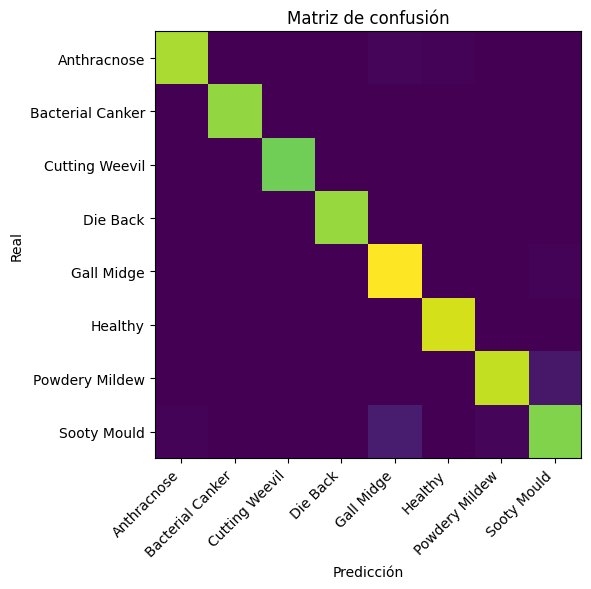

In [31]:
# Visualización matriz de confusión
plt.figure(figsize=(6, 6))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.tight_layout()
plt.show()


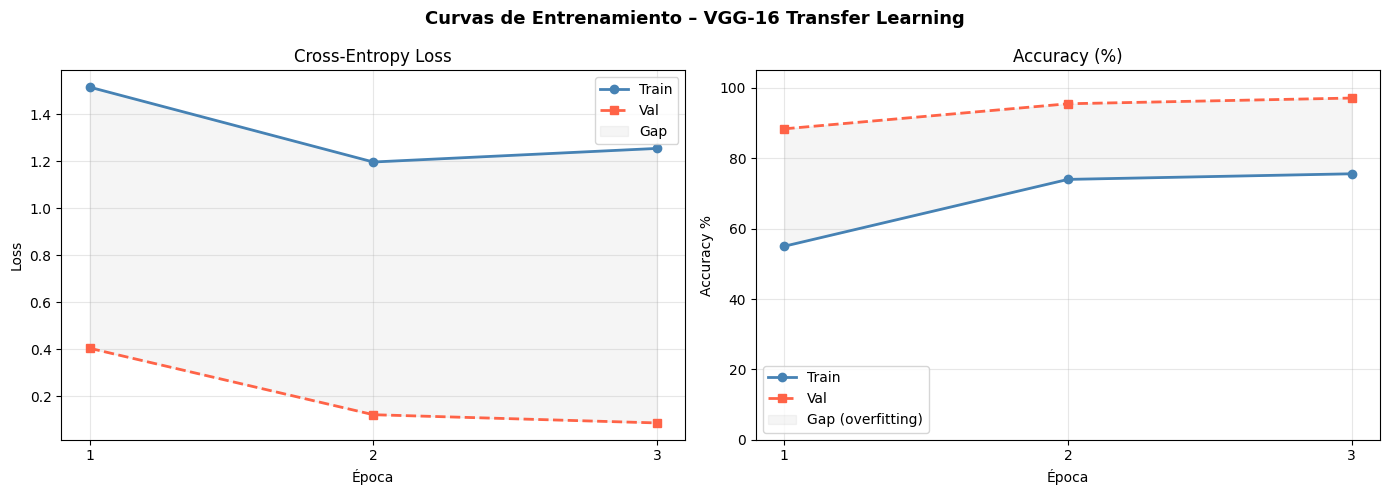

In [32]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Entrenamiento – VGG-16 Transfer Learning", fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs, history["train_loss"], 'o-',  label="Train", color='steelblue', linewidth=2)
axes[0].plot(epochs, history["val_loss"],   's--', label="Val",   color='tomato',    linewidth=2)
axes[0].fill_between(epochs, history["train_loss"], history["val_loss"],
                     alpha=0.08, color='gray', label="Gap")
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xticks(list(epochs))

# Accuracy
train_acc_pct = [a * 100 for a in history["train_acc"]]
val_acc_pct   = [a * 100 for a in history["val_acc"]]
axes[1].plot(epochs, train_acc_pct, 'o-',  label="Train", color='steelblue', linewidth=2)
axes[1].plot(epochs, val_acc_pct,   's--', label="Val",   color='tomato',    linewidth=2)
axes[1].fill_between(epochs, train_acc_pct, val_acc_pct,
                     alpha=0.08, color='gray', label="Gap (overfitting)")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy %")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(list(epochs))
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()


C:\Users\sergi\AppData\Local\Temp\ipykernel_23692\2062348957.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=40, ha='right')


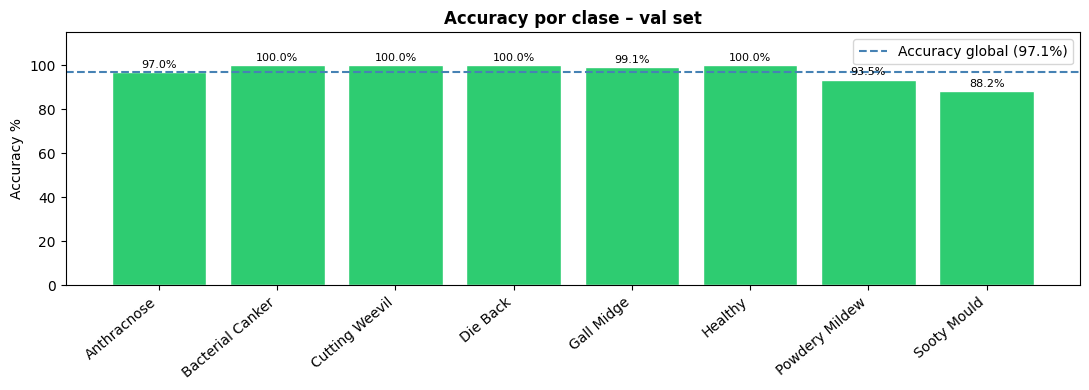

In [33]:
cm = np.array(cm)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm / row_sums

per_class_acc = cm_norm.diagonal() * 100

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 50 else '#e74c3c'
          for a in per_class_acc]
bars = ax.bar(class_names, per_class_acc, color=colors, edgecolor='white')
ax.axhline(acc * 100, color='steelblue', linestyle='--', linewidth=1.5,
           label=f"Accuracy global ({acc*100:.1f}%)")
ax.set_title("Accuracy por clase – val set", fontweight='bold')
ax.set_ylabel("Accuracy %"); ax.set_ylim(0, 115)
ax.set_xticklabels(class_names, rotation=40, ha='right')
ax.legend()

for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


c:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


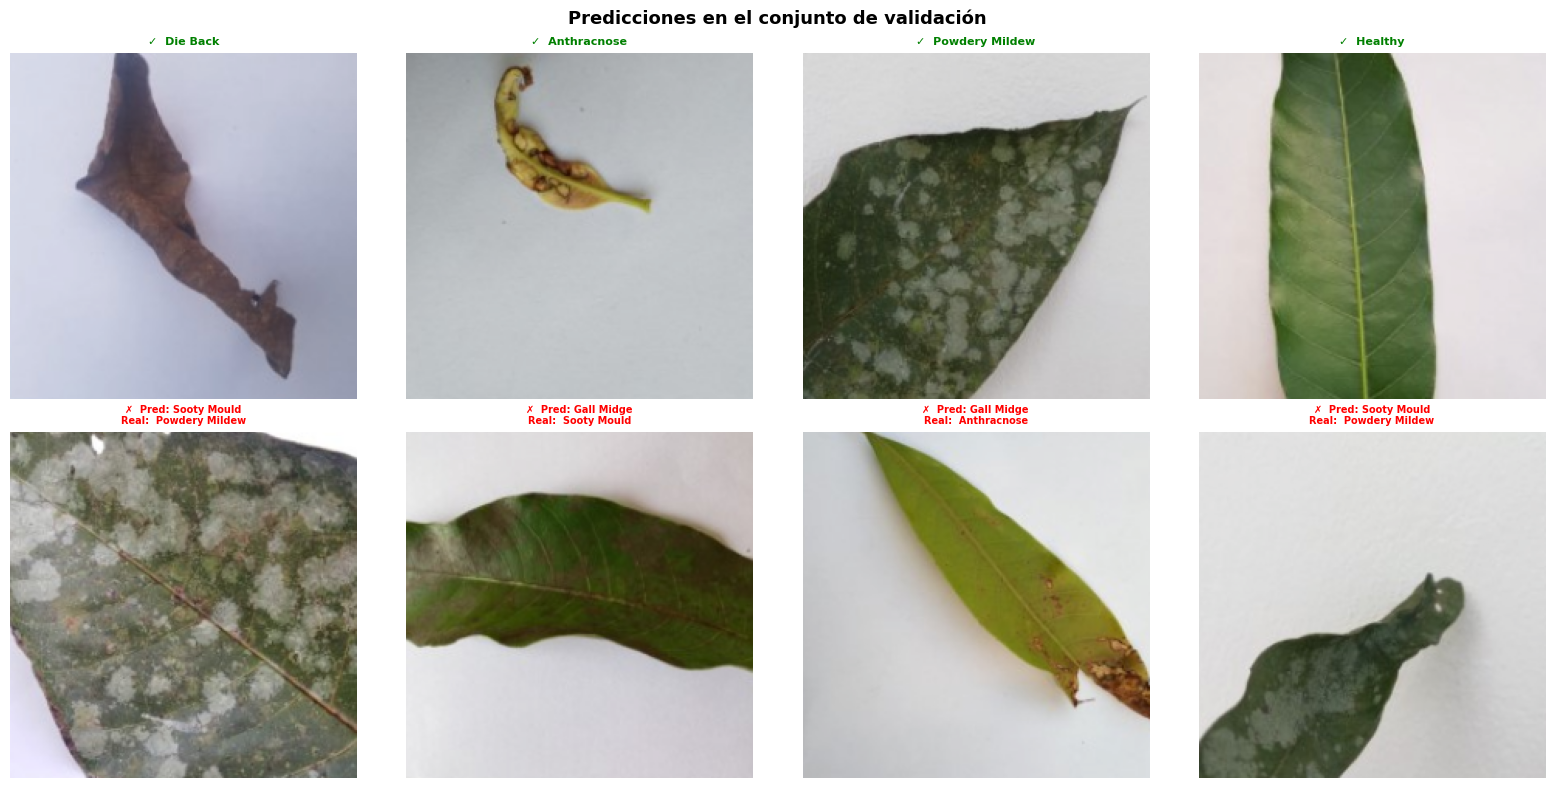

In [34]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485,0.456,0.406], [0.229,0.224,0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]])

correct_imgs, wrong_imgs = [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        logits = model(x.to(device))
        preds  = logits.argmax(dim=1).cpu()
        for i in range(len(y)):
            img_disp = inv_normalize(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
            entry = (img_disp, y[i].item(), preds[i].item())
            if preds[i] == y[i] and len(correct_imgs) < 4:
                correct_imgs.append(entry)
            elif preds[i] != y[i] and len(wrong_imgs) < 4:
                wrong_imgs.append(entry)
        if len(correct_imgs) >= 4 and len(wrong_imgs) >= 4:
            break

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Predicciones en el conjunto de validación", fontsize=13, fontweight='bold')

for ax, (img, true, pred) in zip(axes[0], correct_imgs):
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"✓  {class_names[pred]}", color='green', fontsize=8, fontweight='bold')

for ax, (img, true, pred) in zip(axes[1], wrong_imgs):
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"✗  Pred: {class_names[pred]}\nReal:  {class_names[true]}",
                 color='red', fontsize=7, fontweight='bold')

axes[0][0].set_ylabel("Correctas",   fontsize=10, fontweight='bold', color='green')
axes[1][0].set_ylabel("Incorrectas", fontsize=10, fontweight='bold', color='red')
plt.tight_layout()
plt.show()


###  **Reporte**

#### i) **Precisión global (Accuracy)**
$Accuracy=0.97125$

#### ii) **Matriz de confusión**
Se incluyó la matriz de confusión calculada con `confusion_matrix(all_true, all_pred)` y su visualización en el notebook. La figura muestra una matriz mayormente diagonal, lo cual indica que la mayoría de las clases se predicen correctamente; además, los pocos valores fuera de la diagonal representan confusiones puntuales.

#### iii) **Conclusión**
No se observo sobreajuste marcado porque la precisión de validación es muy alta y se mantiene estable a lo largo del entrenamiento.  Además, la validación supera al entrenamiento, lo cual es consistente con el uso de augmentations en train que vuelven ese conjunto más difícil.  Si existiera otro escenario en donde  train sube mientras val cae, es recomendable incrementar  Dropout en el clasificador para regularizar y reducir co-adaptaciones.
